# Problem Statement 1: -
Kitabi Duniya, a famous book store in India, which was established before Independence, the growth of the company was incremental year by year, but due to online selling of books and wide spread Internet access its annual growth started to collapse, seeing sharp downfalls, you as a Data Scientist help this heritage book store gain its popularity back and increase footfall of customers and provide ways the business can improve exponentially, apply Association RuleAlgorithm, explain the rules, and visualize the graphs for clear understanding of solution.
1.) Books.csv


Business Objective :

The goal is to study how customers buy books to help Kitabi Duniya, a traditional bookstore, become popular again, attract more visitors, and earn more money by suggesting better book pairings and selling methods.

Constraints:

Dataset columns are binary (0 and 1), indicating whether a customer has bought a certain category of books.
Business goal is to understand customer purchase behavior to design marketing strategies or product recommendations.

In [5]:
#import reuired libraries
import pandas as pd
import numpy as np
df=pd.read_csv("F:/Data science/Assignments/PCA assignment/book (1).csv")

In [6]:
# Dataset Exploration and Data Dictionary
df.head(5)

,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence
0,0,1,0,1,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,1,0,1,0,0,0,0
4,0,0,1,0,0,0,1,0,0,0,0


In [7]:
#shape of dataset
df.shape

(2000, 11)

In [8]:
#data dictionary of dataset
df.describe()

,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.423000,0.247500,0.43100,0.282000,0.214500,0.241000,0.276000,0.113500,0.037000,0.048500,0.108500
std,0.494159,0.431668,0.49534,0.450086,0.410578,0.427797,0.447129,0.317282,0.188809,0.214874,0.311089
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.00000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
# Data Pre-processing
#Check for missing values
df.isnull().sum()

ChildBks     0
YouthBks     0
CookBks      0
DoItYBks     0
RefBks       0
ArtBks       0
GeogBks      0
ItalCook     0
ItalAtlas    0
ItalArt      0
Florence     0
dtype: int64

In [10]:
#fill the missing values
df.fillna(0, inplace=True)

In [11]:
#Confirm that missing values are handled
print("\nAfter filling missing values:")
print(df.isnull().sum())


After filling missing values:
ChildBks     0
YouthBks     0
CookBks      0
DoItYBks     0
RefBks       0
ArtBks       0
GeogBks      0
ItalCook     0
ItalAtlas    0
ItalArt      0
Florence     0
dtype: int64


In [12]:
#import necessary libraries to apply association rule
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [13]:
# Step 1: The dataset is already in the correct binary format (0/1), so no need for TransactionEncoder
# Ensure it's binary
print("\nUnique values in the dataset (should be 0 and 1):")
for column in df.columns:
    print(f"{column}: {df[column].unique()}")


Unique values in the dataset (should be 0 and 1):
ChildBks: [0 1]
YouthBks: [1 0]
CookBks: [0 1]
DoItYBks: [1 0]
RefBks: [0 1]
ArtBks: [0 1]
GeogBks: [1 0]
ItalCook: [0 1]
ItalAtlas: [0 1]
ItalArt: [0 1]
Florence: [0 1]


In [14]:
# Step 2: Apply the Apriori algorithm to find frequent itemsets with a minimum support of 0.1 (adjustable)
frequent_itemsets = apriori(df, min_support=0.1, use_colnames=True)

C:\Users\Sai\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [15]:
# Step 3: Generate association rules from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

In [19]:
# Step 4: Output the results
print("\nFrequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
    support                       itemsets
0    0.4230                     (ChildBks)
1    0.2475                     (YouthBks)
2    0.4310                      (CookBks)
3    0.2820                     (DoItYBks)
4    0.2145                       (RefBks)
5    0.2410                       (ArtBks)
6    0.2760                      (GeogBks)
7    0.1135                     (ItalCook)
8    0.1085                     (Florence)
9    0.1650           (YouthBks, ChildBks)
10   0.2560            (CookBks, ChildBks)
11   0.1840           (DoItYBks, ChildBks)
12   0.1515             (RefBks, ChildBks)
13   0.1625             (ArtBks, ChildBks)
14   0.1950            (GeogBks, ChildBks)
15   0.1620            (CookBks, YouthBks)
16   0.1155           (DoItYBks, YouthBks)
17   0.1010             (ArtBks, YouthBks)
18   0.1205            (YouthBks, GeogBks)
19   0.1875            (DoItYBks, CookBks)
20   0.1525              (CookBks, RefBks)
21   0.1670              (ArtBks, 

In [25]:
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Association Rules:
           antecedents         consequents  support  confidence      lift
0           (YouthBks)          (ChildBks)   0.1650    0.666667  1.576044
1           (ChildBks)          (YouthBks)   0.1650    0.390071  1.576044
2            (CookBks)          (ChildBks)   0.2560    0.593968  1.404179
3           (ChildBks)           (CookBks)   0.2560    0.605201  1.404179
4           (DoItYBks)          (ChildBks)   0.1840    0.652482  1.542511
..                 ...                 ...      ...         ...       ...
95   (ArtBks, GeogBks)           (CookBks)   0.1035    0.811765  1.883445
96  (CookBks, GeogBks)            (ArtBks)   0.1035    0.537662  2.230964
97            (ArtBks)  (CookBks, GeogBks)   0.1035    0.429461  2.230964
98           (CookBks)   (ArtBks, GeogBks)   0.1035    0.240139  1.883445
99           (GeogBks)   (ArtBks, CookBks)   0.1035    0.375000  2.245509

[100 rows x 5 columns]


In [26]:
#Plot Frequent Itemsets
import matplotlib.pyplot as plt

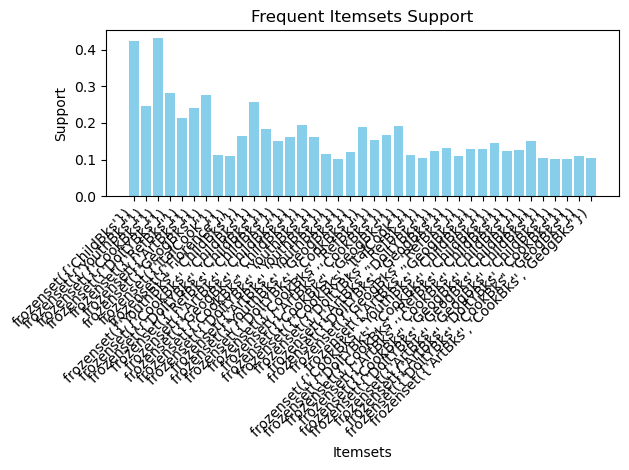

In [27]:
# plt.figure(figsize=(12, 6))
plt.bar(x=frequent_itemsets['itemsets'].astype(str), height=frequent_itemsets['support'], color='skyblue')
plt.title('Frequent Itemsets Support')
plt.xlabel('Itemsets')
plt.ylabel('Support')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Benefits/Impact of the Solution for Kitabi Duniya:

Increased Sales

Improved Inventory Management

Enhanced Customer Experience

Etc.